In [72]:
import sys
!{sys.executable} -m pip install scipy==1.12

In [73]:
import scipy
import gensim

print(scipy.__version__)
print(gensim.__version__)

1.12.0
4.3.2


In [74]:
!pip install pyLDAvis wordcloud gensim -q

In [75]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import nltk
import spacy
from bs4 import BeautifulSoup
import contractions


# Gensim (LDA)
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel

# Sklearn (LSA, NMF, TF-IDF)
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.preprocessing import Normalizer

# Visualization
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords

# spaCy model
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'])
    nlp = spacy.load('en_core_web_sm')

print('✅ All imports successful')

✅ All imports successful


In [76]:
#Retrieve the dataset without having to import the dataset again

%store -r disneyland_df

In [77]:
disneyland_df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [78]:
def clean_text_total(text):
    """
    Clean raw text by removing noise.
    
    Steps:
        1. Remove HTML tags (e.g., <p>, <div>, <br>)
        2. Remove URLs (http://, https://, www.)
        3. Remove email addresses
        4. Normalize whitespace (multiple spaces → single space)
    
    Parameters:
        text (str): Raw text string
    
    Returns:
        str: Cleaned text string
    
    Example:
        >>> clean_text("<p>Visit http://example.com or email test@mail.com</p>")
        'Visit or email'
    """
    # Handle missing values
    if pd.isna(text):
        return ""
    
    # Convert to string
    text = str(text)
    
    # Step 1: Remove HTML tags
    # Pattern: <anything> where anything doesn't contain >
    text = re.sub(r'<[^>]+>', '', text)
    
    # Step 2: Remove URLs
    # Pattern: http(s):// or www. followed by non-whitespace
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # Step 3: Remove email addresses
    # Pattern: something@something.something
    text = re.sub(r'\S+@\S+', '', text)

    #Step 4: Catch any additional HTML that didn't make it through the initial cleaning steps.
    text= BeautifulSoup(text, "html.parser").get_text()
    
    # Step 4: Normalize whitespace
    # Replace multiple spaces/tabs/newlines with single space
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 5: Expand contractions
    text=contractions.fix(text)

    #Removes Punctuation which isn't necessary for topic modeling
    text=re.sub(r'[^a-zA-Z ]', ' ', text)

    text=text.lower()

    return text

def tokenize(text):
    doc = nlp(text, disable=['parser', 'ner'])
    tokens = [
        token.lemma_ for token in doc
        if token.lemma_ not in STOP_WORDS
        and token.is_alpha
        and len(token.lemma_) > 2
    ]
    return tokens

In [79]:
disneyland_df['review_cleaned']=disneyland_df['Review_Text'].apply(clean_text_total)

In [80]:
nltk.download('stopwords') #need to download this pre-trained data for using with word tokenizer
#
STOP_WORDS = set(stopwords.words('english'))

# Add domain-specific stopwords that add noise
custom_stopwords = ['disneyland','disney','park','day','time','went','also','really','just','paris','hong','kong','anaheim',
                    'california','los','angeles','france','china','tokyo', 'orlando', 'florida','usa', 'one','two','get','got','make',
                    'made','back','even','still','us', 'like','would','could','should','much','many','lot','lots', 'thing', 'etc', 'french',
                    'chinese','english','things','something','anything','say','said','see','seen','know','think', 'go','going','come','came',
                    'take','took','almost','basically','certainly','completely','definitely','entirely','fully','literally','maybe',
                    'perhaps','probably','quite','really','somewhat','totally','very','actually','anyway','basically','essentially',
                    'generally','somehow','somewhat','though','usually','seem','feel','felt','appears','looks','starts','begins','that',
                    'this','there','down','up']

STOP_WORDS |= set(custom_stopwords)

#Create a new column to store the cleaned text
disneyland_df['clean_review_wo_stopwords']=disneyland_df['review_cleaned'].copy()

#Go through each review and remove any stopwords that exist.
for review in range(0, len(disneyland_df)):
    a = disneyland_df.review_cleaned[review].split()
    sentence=[ x for x in a  if x.casefold() not in STOP_WORDS]
    disneyland_df['clean_review_wo_stopwords'][review]=" ".join(sentence)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ysass\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [81]:
disneyland_df['clean_review_wo_stopwords']

0        ever anywhere find similar layout walk main st...
1        since last visit hk yet stay tomorrowland aka ...
2        thanks god hot humid visiting otherwise big is...
3        hk great compact unfortunately bit maintenance...
4        location city around hour kowlon kids everythi...
                               ...                        
42651    july thought brilliant visited hotels stayed n...
42652    adults child visited beginning feb absolute fa...
42653    eleven year old daughter visit son london deci...
42654    hotel part complex wonderful place families si...
42655    disneyparis resort small child minute enter tr...
Name: clean_review_wo_stopwords, Length: 42656, dtype: object

In [82]:
disneyland_df['clean_review_wo_stopwords']=disneyland_df['clean_review_wo_stopwords'].str.lower()

In [83]:
def most_popular_words(dataframe):
    words=dataframe['clean_review_wo_stopwords'].str.split()
    all_words=words.explode()
    all_words_standard=all_words.str.lower()
    word_counts=all_words_standard.value_counts()
    top_n_words=word_counts.index[:10]
    return top_n_words

In [84]:
print('Preprocessing... (may take ~60s)')
disneyland_df['tokenized_texts'] = disneyland_df['clean_review_wo_stopwords'].apply(tokenize)

Preprocessing... (may take ~60s)


In [85]:
disneyland_df['cleaned_texts'] = [' '.join(t) for t in disneyland_df['tokenized_texts']]

In [86]:
#Break Down the Different Categories
california_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_California']
hong_kong_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_HongKong']
paris_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_Paris']

In [87]:
disneyland_df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,review_cleaned,clean_review_wo_stopwords,tokenized_texts,cleaned_texts
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,if you have ever been to disneyland anywhere y...,ever anywhere find similar layout walk main st...,"[ever, anywhere, find, similar, layout, walk, ...",ever anywhere find similar layout walk main st...
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,its been a while since d last time we visit hk...,since last visit hk yet stay tomorrowland aka ...,"[since, last, visit, yet, stay, tomorrowland, ...",since last visit yet stay tomorrowland aka mar...
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,thanks god it wasn t too hot or too humid when...,thanks god hot humid visiting otherwise big is...,"[thank, god, hot, humid, visit, otherwise, big...",thank god hot humid visit otherwise big issue ...
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,hk disneyland is a great compact park unfortu...,hk great compact unfortunately bit maintenance...,"[great, compact, unfortunately, bit, maintenan...",great compact unfortunately bit maintenance wo...
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,the location is not in the city took around ...,location city around hour kowlon kids everythi...,"[location, city, around, hour, kowlon, kid, ev...",location city around hour kowlon kid everythin...
...,...,...,...,...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris,i went to disneyland paris in july and thou...,july thought brilliant visited hotels stayed n...,"[july, brilliant, visit, hotel, stay, newport,...",july brilliant visit hotel stay newport bay ky...
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris,adults and child of visited disneyland ...,adults child visited beginning feb absolute fa...,"[adult, child, visit, begin, feb, absolute, fa...",adult child visit begin feb absolute fantastic...
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris,my eleven year old daughter and myself went to...,eleven year old daughter visit son london deci...,"[eleven, year, old, daughter, visit, son, lond...",eleven year old daughter visit son london deci...
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris,this hotel part of the disneyland paris compl...,hotel part complex wonderful place families si...,"[hotel, part, complex, wonderful, place, famil...",hotel part complex wonderful place family sinc...


In [88]:

print(f'The average number of characters in a review (after cleaning) is {disneyland_df['clean_review_wo_stopwords'].str.len().mean()} characters.')
print(f'The average number of characters in a California review (after cleaning) is {california_reviews['clean_review_wo_stopwords'].str.len().mean()} characters.')
print(f'The average number of characters in a Paris review (after cleaning) is {paris_reviews['clean_review_wo_stopwords'].str.len().mean()} characters.')
print(f'The average number of characters in a Disneyland review (after cleaning) is {hong_kong_reviews['clean_review_wo_stopwords'].str.len().mean()} characters.')

#2.3.2 Vocabulary
#These reviews contain no emojis, more casual language, language that could be used to heighten emotion (contain emphasis). There are also certain cases where words
#are written in all caps. Depending on the person who wrote it there are some reviews that are more sopisticated in terms of word choice while other people used more 
#simple vocabulary. 

#2.3.3 Common words per class and label
print(f'The top 10 most popular words in California reviews (after cleaning) are {', '.join(most_popular_words(california_reviews))}.')
print(f'The top 10 most popular words in Paris reviews (after cleaning) are {', '.join(most_popular_words(paris_reviews))}.')
print(f'The top 10 most popular words in Hong Kong (after cleaning) reviews are {', '.join(most_popular_words(hong_kong_reviews))}.')

The average number of characters in a review (after cleaning) is 353.4716100900225 characters.
The average number of characters in a California review (after cleaning) is 311.49464083273216 characters.
The average number of characters in a Paris review (after cleaning) is 464.58840792369773 characters.
The average number of characters in a Disneyland review (after cleaning) is 280.7151767151767 characters.
The top 10 most popular words in California reviews (after cleaning) are rides, ride, great, place, pass, fast, kids, wait, fun, people.
The top 10 most popular words in Paris reviews (after cleaning) are rides, food, ride, good, great, parks, kids, queues, people, staff.
The top 10 most popular words in Hong Kong (after cleaning) reviews are rides, kids, food, place, great, ride, visit, good, parade, small.


In [89]:
# Vocabulary for each group
text_combined_hong_kong = " ".join(hong_kong_reviews['clean_review_wo_stopwords'].dropna().str.lower())
text_combined_paris = " ".join(paris_reviews['clean_review_wo_stopwords'].dropna().str.lower())
text_combined_california = " ".join(california_reviews['clean_review_wo_stopwords'].dropna().str.lower())

individual_words_hong_kong=text_combined_hong_kong.split()
individual_words_paris=text_combined_paris.split()
individual_words_california=text_combined_california.split()

# Get the unique words (vocabulary) using a set
vocabulary_hong_kong = set(individual_words_hong_kong)
vocabulary_paris = set(individual_words_paris)
vocabulary_california = set(individual_words_california)

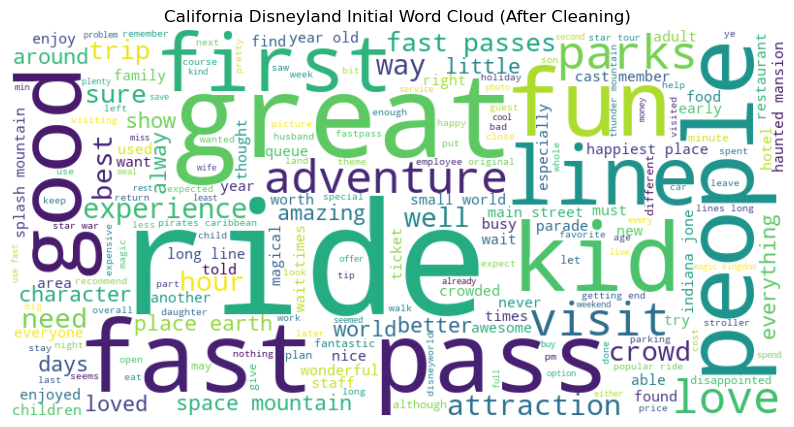

In [90]:
from wordcloud import WordCloud, STOPWORDS

text_combined = " ".join(california_reviews['clean_review_wo_stopwords'].dropna().str.lower())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 8))
plt.title('California Disneyland Initial Word Cloud (After Cleaning)')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

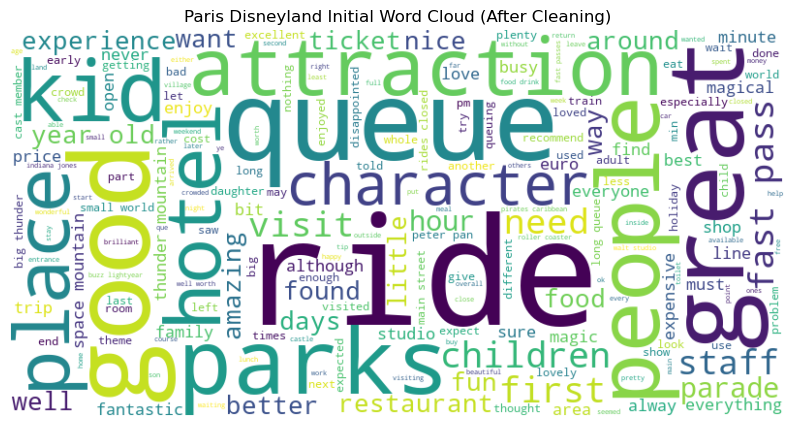

In [91]:
text_combined = " ".join(paris_reviews['clean_review_wo_stopwords'].dropna().str.lower())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 8))
plt.title('Paris Disneyland Initial Word Cloud (After Cleaning)')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

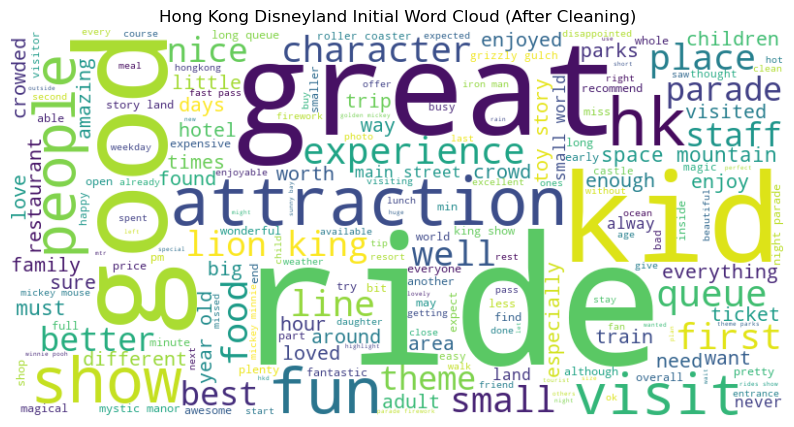

In [92]:
text_combined = " ".join(hong_kong_reviews['clean_review_wo_stopwords'].dropna().str.lower())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 8))
plt.title('Hong Kong Disneyland Initial Word Cloud (After Cleaning)')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [93]:
disneyland_df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,review_cleaned,clean_review_wo_stopwords,tokenized_texts,cleaned_texts
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,if you have ever been to disneyland anywhere y...,ever anywhere find similar layout walk main st...,"[ever, anywhere, find, similar, layout, walk, ...",ever anywhere find similar layout walk main st...
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,its been a while since d last time we visit hk...,since last visit hk yet stay tomorrowland aka ...,"[since, last, visit, yet, stay, tomorrowland, ...",since last visit yet stay tomorrowland aka mar...
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,thanks god it wasn t too hot or too humid when...,thanks god hot humid visiting otherwise big is...,"[thank, god, hot, humid, visit, otherwise, big...",thank god hot humid visit otherwise big issue ...
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,hk disneyland is a great compact park unfortu...,hk great compact unfortunately bit maintenance...,"[great, compact, unfortunately, bit, maintenan...",great compact unfortunately bit maintenance wo...
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,the location is not in the city took around ...,location city around hour kowlon kids everythi...,"[location, city, around, hour, kowlon, kid, ev...",location city around hour kowlon kid everythin...
...,...,...,...,...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris,i went to disneyland paris in july and thou...,july thought brilliant visited hotels stayed n...,"[july, brilliant, visit, hotel, stay, newport,...",july brilliant visit hotel stay newport bay ky...
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris,adults and child of visited disneyland ...,adults child visited beginning feb absolute fa...,"[adult, child, visit, begin, feb, absolute, fa...",adult child visit begin feb absolute fantastic...
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris,my eleven year old daughter and myself went to...,eleven year old daughter visit son london deci...,"[eleven, year, old, daughter, visit, son, lond...",eleven year old daughter visit son london deci...
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris,this hotel part of the disneyland paris compl...,hotel part complex wonderful place families si...,"[hotel, part, complex, wonderful, place, famil...",hotel part complex wonderful place family sinc...


In [94]:
lengths = [len(t) for t in disneyland_df['tokenized_texts']]
print(f'Median tokens per doc: {np.median(lengths):.0f}')
print(f'Min: {min(lengths)}, Max: {max(lengths)}')

# Remove very short docs (< 5 tokens) — not enough signal for topic modeling
mask = [i for i, t in enumerate(disneyland_df['tokenized_texts']) if len(t) >= 5]
drop_index = [i for i, t in enumerate(disneyland_df['tokenized_texts']) if len(t) < 5]
tokenized_texts = [disneyland_df['tokenized_texts'][i] for i in mask]
cleaned_texts   = [disneyland_df['cleaned_texts'][i]   for i in mask]
print(f'Kept {len(tokenized_texts)}/{len(disneyland_df)} documents (≥5 tokens)')

Median tokens per doc: 30
Min: 1, Max: 1433
Kept 42478/42656 documents (≥5 tokens)


In [95]:
# Remove very short docs (< 5 tokens) — not enough signal for topic modeling
disneyland_df=disneyland_df[disneyland_df['tokenized_texts'].str.len() >=5]

In [96]:
# Store the dataframe variable so we can use it in the exact same state in the next notebook
%store disneyland_df

Stored 'disneyland_df' (DataFrame)


In [97]:
disneyland_df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,review_cleaned,clean_review_wo_stopwords,tokenized_texts,cleaned_texts
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,if you have ever been to disneyland anywhere y...,ever anywhere find similar layout walk main st...,"[ever, anywhere, find, similar, layout, walk, ...",ever anywhere find similar layout walk main st...
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,its been a while since d last time we visit hk...,since last visit hk yet stay tomorrowland aka ...,"[since, last, visit, yet, stay, tomorrowland, ...",since last visit yet stay tomorrowland aka mar...
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,thanks god it wasn t too hot or too humid when...,thanks god hot humid visiting otherwise big is...,"[thank, god, hot, humid, visit, otherwise, big...",thank god hot humid visit otherwise big issue ...
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,hk disneyland is a great compact park unfortu...,hk great compact unfortunately bit maintenance...,"[great, compact, unfortunately, bit, maintenan...",great compact unfortunately bit maintenance wo...
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,the location is not in the city took around ...,location city around hour kowlon kids everythi...,"[location, city, around, hour, kowlon, kid, ev...",location city around hour kowlon kid everythin...
...,...,...,...,...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris,i went to disneyland paris in july and thou...,july thought brilliant visited hotels stayed n...,"[july, brilliant, visit, hotel, stay, newport,...",july brilliant visit hotel stay newport bay ky...
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris,adults and child of visited disneyland ...,adults child visited beginning feb absolute fa...,"[adult, child, visit, begin, feb, absolute, fa...",adult child visit begin feb absolute fantastic...
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris,my eleven year old daughter and myself went to...,eleven year old daughter visit son london deci...,"[eleven, year, old, daughter, visit, son, lond...",eleven year old daughter visit son london deci...
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris,this hotel part of the disneyland paris compl...,hotel part complex wonderful place families si...,"[hotel, part, complex, wonderful, place, famil...",hotel part complex wonderful place family sinc...
